In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau
from sklearn.preprocessing import OrdinalEncoder
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight


In [18]:
df = pd.read_csv("/content/Car_Insurance_Claim.csv")

df.head()

,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [19]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_V

In [20]:
df.isnull().sum().sort_values(ascending=False)

,0
CREDIT_SCORE,982
ANNUAL_MILEAGE,957
ID,0
GENDER,0
AGE,0
EDUCATION,0
RACE,0
INCOME,0
VEHICLE_OWNERSHIP,0
VEHICLE_YEAR,0


In [21]:
df["OUTCOME"].value_counts()

,count
OUTCOME,
0.0,6867
1.0,3133


In [22]:
df["OUTCOME"].value_counts(normalize=True) * 100

,proportion
OUTCOME,
0.0,68.67
1.0,31.33


In [23]:
df["CREDIT_SCORE"] = df["CREDIT_SCORE"].fillna(df["CREDIT_SCORE"].median())

df["ANNUAL_MILEAGE"] = df["ANNUAL_MILEAGE"].fillna(df["ANNUAL_MILEAGE"].median())

In [24]:
df.isnull().sum()

,0
ID,0
AGE,0
GENDER,0
RACE,0
DRIVING_EXPERIENCE,0
EDUCATION,0
INCOME,0
CREDIT_SCORE,0
VEHICLE_OWNERSHIP,0
VEHICLE_YEAR,0


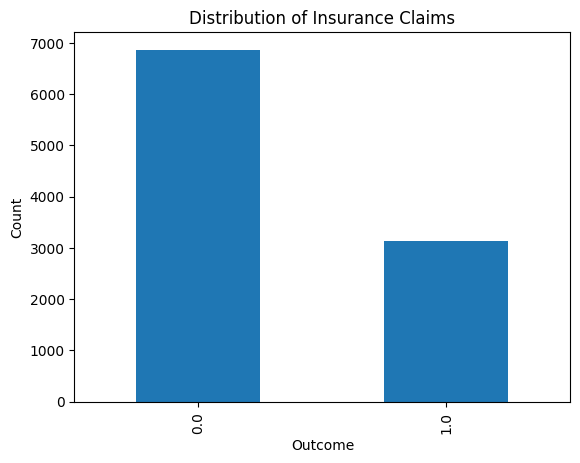

In [25]:
df["OUTCOME"].value_counts().plot(kind="bar")
plt.title("Distribution of Insurance Claims")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

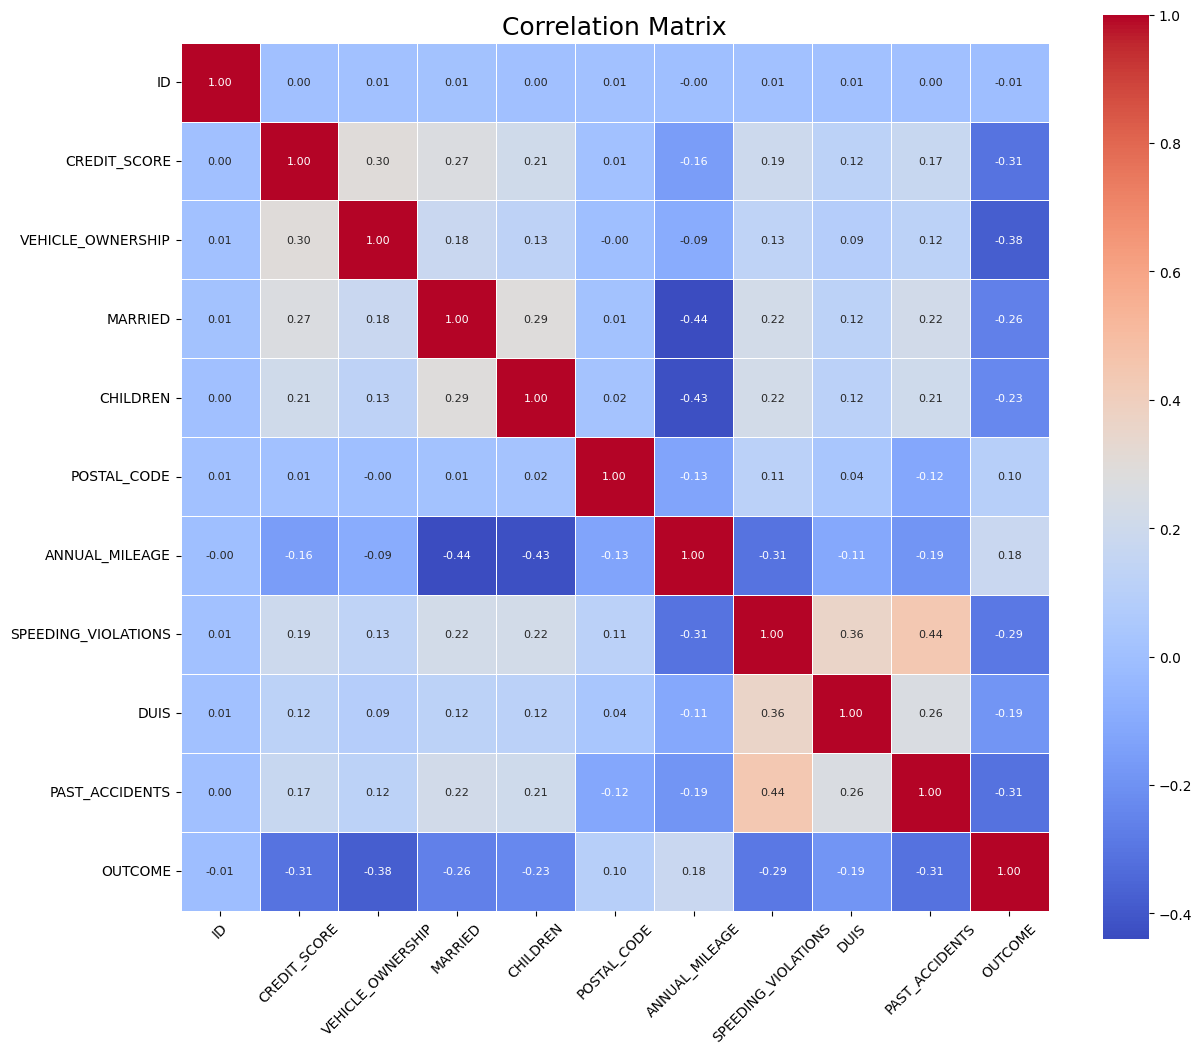

In [26]:
import seaborn as sns

plt.figure(figsize=(14,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    annot_kws={"size":8}
)

plt.title("Correlation Matrix", fontsize=18)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [27]:
df.drop(["ID", "POSTAL_CODE"], axis=1, inplace=True) # chnage (add POSTAL_CODE)

In [28]:
X = df.drop("OUTCOME", axis=1)
y = df["OUTCOME"]

In [29]:
X.select_dtypes(include="object").columns

Index(['AGE', 'GENDER', 'RACE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME',
       'VEHICLE_YEAR', 'VEHICLE_TYPE'],
      dtype='object')

In [30]:
X.shape

(10000, 16)

#Part 2

In [31]:
age_order = ['16-25', '26-39', '40-64', '65+']
driving_experience_order = ['0-9y', '10-19y', '20-29y', '30y+']
education_order = ['none', 'high school', 'university']
income_order = ['poverty', 'working class', 'middle class', 'upper class']
vehicle_year_order = ['before 2015', 'after 2015']

ordinal_cols = ['AGE', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR']
onehot_cols = ['GENDER', 'RACE', 'VEHICLE_TYPE']

ordinal_encoder = OrdinalEncoder(categories=[
    age_order, driving_experience_order, education_order,
    income_order, vehicle_year_order
])
# chnage (add ordinal encoding)

In [32]:
X[ordinal_cols] = ordinal_encoder.fit_transform(X[ordinal_cols])  # chnage (add ordinal encoding)

In [33]:
X = pd.get_dummies(X, columns=onehot_cols, drop_first=True, dtype=int) # chnage (add onehot encoding)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(8000, 16)
(2000, 16)
(8000,)
(2000,)


# Deep Learning

In [37]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [39]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7589 - loss: 0.4731 - val_accuracy: 0.8194 - val_loss: 0.4047
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8205 - loss: 0.3970 - val_accuracy: 0.8300 - val_loss: 0.3979
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.3862 - val_accuracy: 0.8300 - val_loss: 0.3969
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8319 - loss: 0.3788 - val_accuracy: 0.8344 - val_loss: 0.3912
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8317 - loss: 0.3735 - val_accuracy: 0.8375 - val_loss: 0.3876
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8352 - loss: 0.3735 - val_accuracy: 0.8369 - val_loss: 0.3900
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8352 - loss: 0.3670 - val_accuracy: 0.8388 - val_loss: 0.3898
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8402 - loss: 0.3662 - val_accuracy: 0.

In [40]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8235 - loss: 0.3955
Test Loss: 0.3954704999923706
Test Accuracy: 0.8234999775886536


In [41]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


              precision    recall  f1-score   support

         0.0       0.91      0.80      0.85      1373
         1.0       0.65      0.83      0.73       627

    accuracy                           0.81      2000
   macro avg       0.78      0.81      0.79      2000
weighted avg       0.83      0.81      0.81      2000



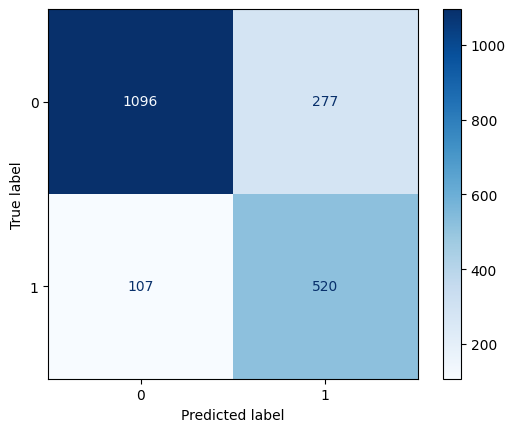

In [79]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.show()

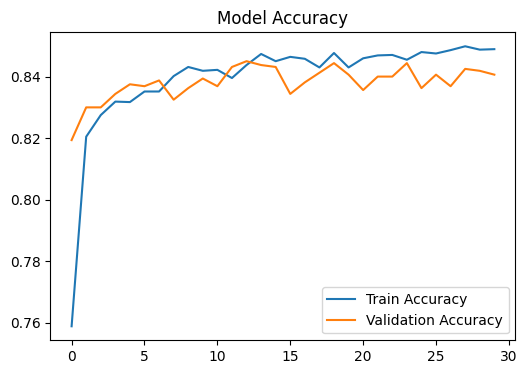

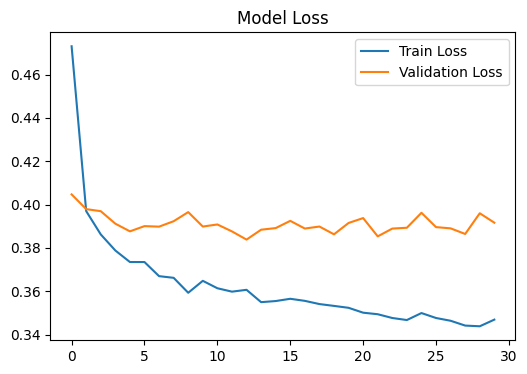

In [43]:
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Model Loss")
plt.show()

# Imroved ANN

In [44]:
model2 = Sequential([
    Dense(64, activation="relu",
          kernel_regularizer=l2(0.001),
          input_shape=(X_train.shape[1],)),

    Dropout(0.3),

    Dense(32, activation="relu",
          kernel_regularizer=l2(0.001)),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7650 - loss: 0.5423 - val_accuracy: 0.8231 - val_loss: 0.4690
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8170 - loss: 0.4612 - val_accuracy: 0.8306 - val_loss: 0.4465
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8263 - loss: 0.4399 - val_accuracy: 0.8363 - val_loss: 0.4392
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8342 - loss: 0.4255 - val_accuracy: 0.8388 - val_loss: 0.4309
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8350 - loss: 0.4146 - val_accuracy: 0.8356 - val_loss: 0.4241
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8377 - loss: 0.4033 - val_accuracy: 0.8400 - val_loss: 0.4218
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.4043 - val_accuracy: 0.8369 - val_loss: 0.4221
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8406 - loss: 0.3951 - val_accuracy: 0.8350 - val_

In [45]:
test_loss, test_accuracy = model2.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8300 - loss: 0.4053
Test Loss: 0.40534740686416626
Test Accuracy: 0.8299999833106995


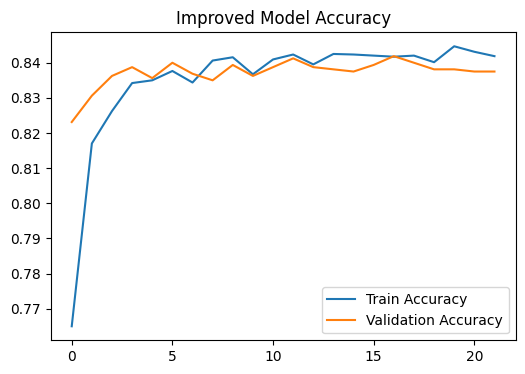

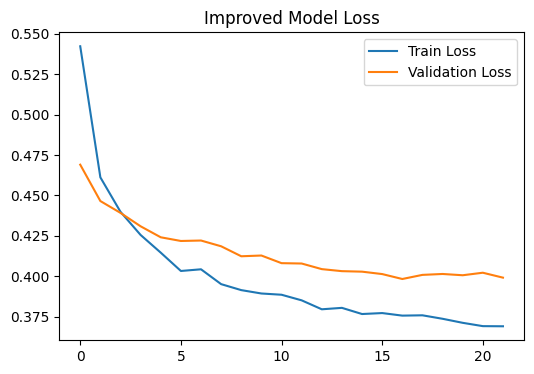

In [46]:
plt.figure(figsize=(6,4))
plt.plot(history2.history["accuracy"], label="Train Accuracy")
plt.plot(history2.history["val_accuracy"], label="Validation Accuracy")
plt.title("Improved Model Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history2.history["loss"], label="Train Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")
plt.title("Improved Model Loss")
plt.legend()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.88      1373
         1.0       0.74      0.71      0.72       627

    accuracy                           0.83      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.83      0.83      0.83      2000



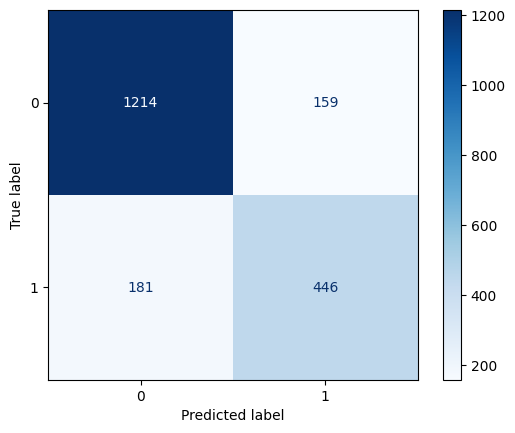

In [89]:
y_pred = (model2.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

# Model3

In [49]:
model3 = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation="relu",
          kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(32, activation="relu",
          kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [50]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

In [51]:
history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7914 - loss: 0.5121 - val_accuracy: 0.8269 - val_loss: 0.4606 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8270 - loss: 0.4454 - val_accuracy: 0.8356 - val_loss: 0.4441 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8298 - loss: 0.4285 - val_accuracy: 0.8356 - val_loss: 0.4355 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8338 - loss: 0.4169 - val_accuracy: 0.8388 - val_loss: 0.4277 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8369 - loss: 0.4092 - val_accuracy: 0.8394 - val_loss: 0.4206 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8373 - loss: 0.4005 - val_accuracy: 0.8406 - val_loss: 0.4200 - learning_rate: 0.0010
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8383 - loss: 0.

In [52]:
test_loss3, test_accuracy3 = model3.evaluate(X_test, y_test)

print("Test Loss:", test_loss3)
print("Test Accuracy:", test_accuracy3)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8310 - loss: 0.4053
Test Loss: 0.40527620911598206
Test Accuracy: 0.8309999704360962


              precision    recall  f1-score   support

         0.0       0.88      0.87      0.88      1373
         1.0       0.73      0.74      0.73       627

    accuracy                           0.83      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.83      0.83      0.83      2000

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


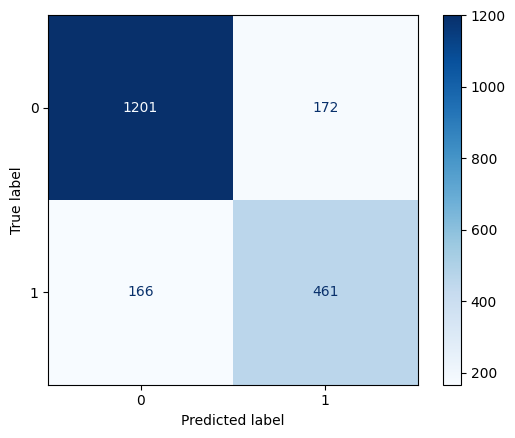

In [84]:
y_pred = (model3.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

# Model4

In [53]:
model4 = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [54]:
early_stop4 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr4 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

In [55]:
history4 = model4.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop4, reduce_lr4],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7978 - loss: 0.4339 - val_accuracy: 0.8156 - val_loss: 0.4049 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8255 - loss: 0.3843 - val_accuracy: 0.8331 - val_loss: 0.3939 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8298 - loss: 0.3817 - val_accuracy: 0.8381 - val_loss: 0.3927 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8314 - loss: 0.3764 - val_accuracy: 0.8363 - val_loss: 0.3900 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8328 - loss: 0.3637 - val_accuracy: 0.8350 - val_loss: 0.3948 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8344 - loss: 0.3711 - val_accuracy: 0.8350 - val_loss: 0.3926 - learning_rate: 0.0010
Epoch 7/100
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8391 - loss: 0.

In [56]:
test_loss4, test_accuracy4 = model4.evaluate(X_test, y_test)

print("Test Loss:", test_loss4)
print("Test Accuracy:", test_accuracy4)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8250 - loss: 0.4021
Test Loss: 0.4020808935165405
Test Accuracy: 0.824999988079071


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.87      1373
         1.0       0.73      0.71      0.72       627

    accuracy                           0.82      2000
   macro avg       0.80      0.79      0.80      2000
weighted avg       0.82      0.82      0.82      2000



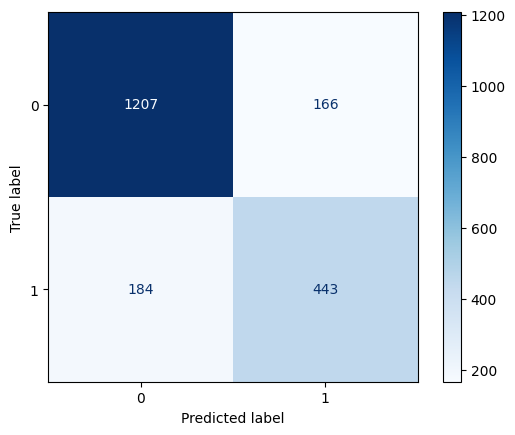

In [88]:
y_pred = (model4.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

#Model5

In [57]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.728066982162359), 1: np.float64(1.596169193934557)}


In [58]:
model5 = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation="relu",
          kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(32, activation="relu",
          kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model5.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop5 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history5 = model5.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop5],
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7573 - loss: 0.5641 - val_accuracy: 0.8006 - val_loss: 0.4987
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7973 - loss: 0.4907 - val_accuracy: 0.8131 - val_loss: 0.4782
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8028 - loss: 0.4739 - val_accuracy: 0.8050 - val_loss: 0.4817
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8080 - loss: 0.4593 - val_accuracy: 0.8169 - val_loss: 0.4524
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8086 - loss: 0.4491 - val_accuracy: 0.8144 - val_loss: 0.4486
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8170 - loss: 0.4408 - val_accuracy: 0.8100 - val_loss: 0.4628
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8202 - loss: 0.4367 - val_accuracy: 0.8119 - val_loss: 0.4508
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8181 - loss: 0.4322 - val_accuracy: 0.

In [59]:
test_loss5, test_accuracy5 = model5.evaluate(X_test, y_test)

print("Test Loss:", test_loss5)
print("Test Accuracy:", test_accuracy5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8080 - loss: 0.4420
Test Loss: 0.44200485944747925
Test Accuracy: 0.8080000281333923


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

         0.0       0.91      0.80      0.85      1373
         1.0       0.65      0.83      0.73       627

    accuracy                           0.81      2000
   macro avg       0.78      0.81      0.79      2000
weighted avg       0.83      0.81      0.81      2000



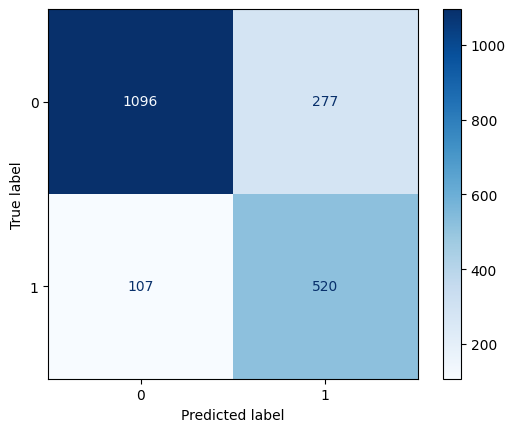

In [87]:
y_pred = (model5.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Best threshold for F1: 0.595
Precision at best threshold: 0.693
Recall at best threshold: 0.793
F1 at best threshold: 0.740

--- Default threshold (0.5) ---
Accuracy: 0.808
              precision    recall  f1-score   support

         0.0       0.91      0.80      0.85      1373
         1.0       0.65      0.83      0.73       627

    accuracy                           0.81      2000
   macro avg       0.78      0.81      0.79      2000
weighted avg       0.83      0.81      0.81      2000


--- Tuned threshold ---
Accuracy: 0.8245
              precision    recall  f1-score   support

         0.0       0.90      0.84      0.87      1373
         1.0       0.69      0.79      0.74       627

    accuracy                           0.82      2000
   macro avg       0.80      0.82      0.80      2000
weighted avg       0.83      0.82      0.83      2000



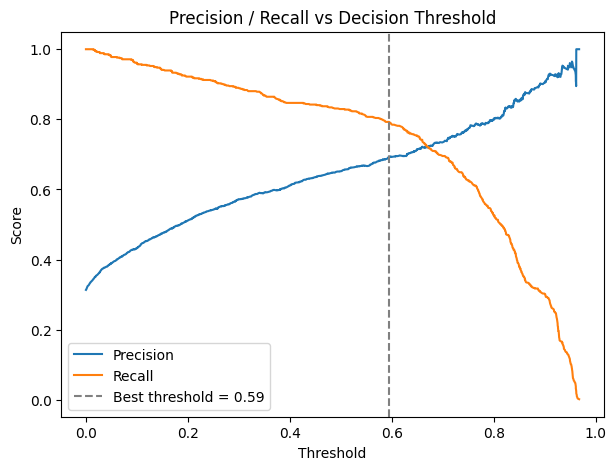

In [70]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get predicted probabilities (not rounded to 0/1)
y_probs = model5.predict(X_test).ravel()

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Compute F1 at each threshold to find the best tradeoff point
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold for F1: {best_threshold:.3f}")
print(f"Precision at best threshold: {precisions[best_idx]:.3f}")
print(f"Recall at best threshold: {recalls[best_idx]:.3f}")
print(f"F1 at best threshold: {f1_scores[best_idx]:.3f}")

# Compare accuracy at 0.5 vs your new threshold
from sklearn.metrics import accuracy_score, classification_report

y_pred_default = (y_probs > 0.5).astype(int)
y_pred_tuned = (y_probs > best_threshold).astype(int)

print("\n--- Default threshold (0.5) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

print("\n--- Tuned threshold ---")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

# Optional: plot precision/recall vs threshold to include in your presentation
plt.figure(figsize=(7,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(best_threshold, color="gray", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs Decision Threshold")
plt.legend()
plt.show()

                  Model  Accuracy  Precision (class 1)  Recall (class 1)  F1 (class 1)
    Model 3 (+ReduceLR)     0.831                0.728             0.735         0.732
Model 5 (+class_weight)     0.808                0.652             0.829         0.730
   Model 2 (L2+Dropout)     0.830                0.737             0.711         0.724
   Model 4 (+BatchNorm)     0.825                0.727             0.707         0.717
     Model 1 (baseline)     0.824                0.736             0.681         0.708


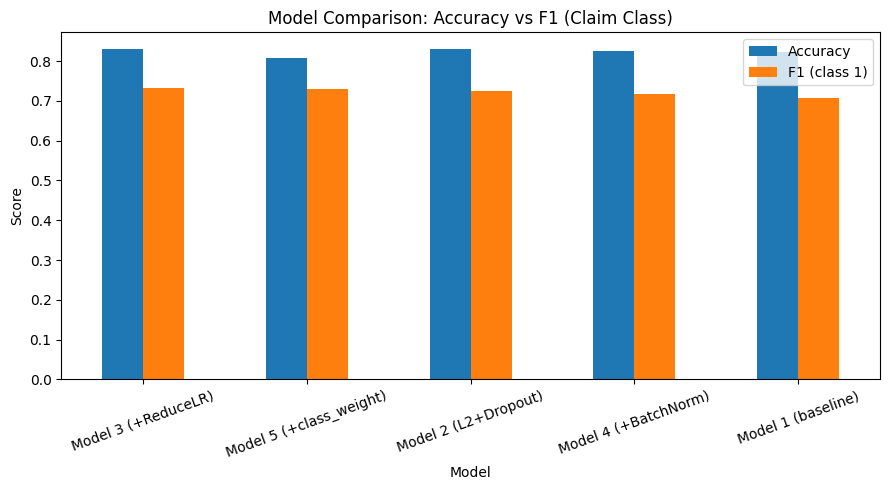

In [78]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_dict = {
    "Model 1 (baseline)": model,
    "Model 2 (L2+Dropout)": model2,
    "Model 3 (+ReduceLR)": model3,
    "Model 4 (+BatchNorm)": model4,
    "Model 5 (+class_weight)": model5,
}

results = []

for name, m in models_dict.items():
    y_probs = m.predict(X_test, verbose=0).ravel()
    y_pred = (y_probs > 0.50).astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (class 1)": precision_score(y_test, y_pred),
        "Recall (class 1)": recall_score(y_test, y_pred),
        "F1 (class 1)": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).round(3)
results_df = results_df.sort_values("F1 (class 1)", ascending=False)
print(results_df.to_string(index=False))

# Optional: bar chart for the presentation
results_df.set_index("Model")[["Accuracy", "F1 (class 1)"]].plot(kind="bar", figsize=(9,5))
plt.title("Model Comparison: Accuracy vs F1 (Claim Class)")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Keras tuner

In [61]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


In [62]:
import keras_tuner as kt


In [63]:
def build_tuned_model(hp):

    tuned_model = Sequential()

    tuned_model.add(
        Input(shape=(X_train.shape[1],))
    )

    # First hidden layer
    tuned_model.add(
        Dense(
            units=hp.Int(
                "units_layer1",
                min_value=32,
                max_value=128,
                step=32
            ),
            activation="relu"
        )
    )

    tuned_model.add(
        Dropout(
            hp.Choice(
                "dropout_layer1",
                values=[0.0, 0.1, 0.2, 0.3]
            )
        )
    )

    # Second hidden layer
    tuned_model.add(
        Dense(
            units=hp.Int(
                "units_layer2",
                min_value=16,
                max_value=64,
                step=16
            ),
            activation="relu"
        )
    )

    tuned_model.add(
        Dropout(
            hp.Choice(
                "dropout_layer2",
                values=[0.0, 0.1, 0.2, 0.3]
            )
        )
    )

    # Output layer
    tuned_model.add(
        Dense(1, activation="sigmoid")
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.001, 0.0005, 0.0001]
    )

    tuned_model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return tuned_model

In [64]:
insurance_tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=1,
    directory="insurance_tuning_results",
    project_name="car_insurance_ann"
)

In [65]:
tuning_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [66]:
insurance_tuner.search(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[tuning_early_stop],
    verbose=1
)

Trial 15 Complete [00h 00m 15s]
val_accuracy: 0.8431249856948853

Best val_accuracy So Far: 0.8462499976158142
Total elapsed time: 00h 05m 45s


In [67]:
best_tuned_hp = insurance_tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print("Best neurons in layer 1:",
      best_tuned_hp.get("units_layer1"))

print("Best neurons in layer 2:",
      best_tuned_hp.get("units_layer2"))

print("Best dropout layer 1:",
      best_tuned_hp.get("dropout_layer1"))

print("Best dropout layer 2:",
      best_tuned_hp.get("dropout_layer2"))

print("Best learning rate:",
      best_tuned_hp.get("learning_rate"))

Best neurons in layer 1: 32
Best neurons in layer 2: 64
Best dropout layer 1: 0.0
Best dropout layer 2: 0.1
Best learning rate: 0.0005


In [68]:
best_tuned_model = insurance_tuner.get_best_models(
    num_models=1
)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [69]:
tuned_test_loss, tuned_test_accuracy = best_tuned_model.evaluate(
    X_test,
    y_test
)

print("Tuned Test Loss:", tuned_test_loss)
print("Tuned Test Accuracy:", tuned_test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8200 - loss: 0.4018
Tuned Test Loss: 0.4017888605594635
Tuned Test Accuracy: 0.8199999928474426
